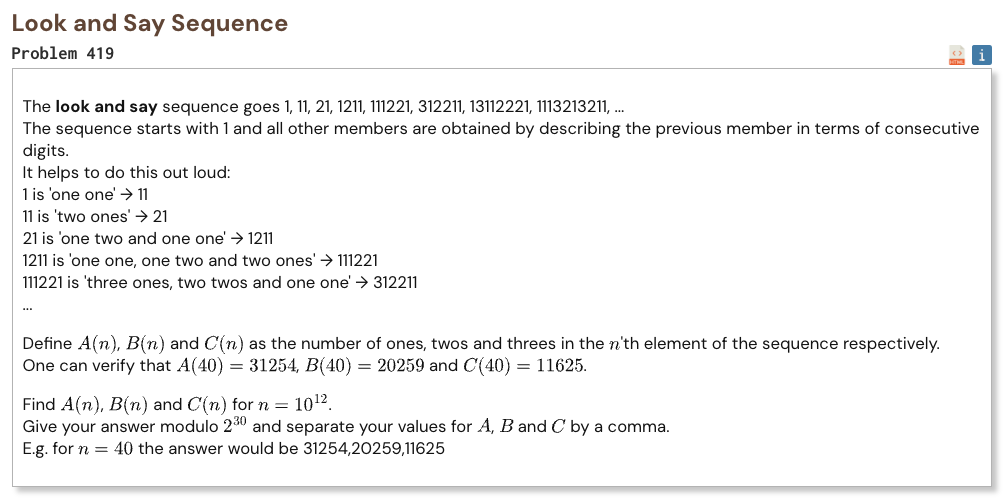

## Initial approach

-   generate a normal look and say term far enough for Conway's stable structure to appear
-   Conway showed that the sequence eventually breaks into only 92 independent pieces called elements
-   use the `look_and_say` library to generate these 92 elements and split the sequence into them
-   each element always changes into a fixed collection of other elements
-   store these changes in a 92 by 92 transition matrix
-   use fast matrix exponentiation to jump from term 40 to term one trillion
-   count how many ones twos and threes are contained in the final collection of elements
-   keep every calculation modulo the required power of two

In [1]:
%%time

from look_and_say import LookAndSay, Chemistry, split_Conway

MOD = 2 ** 30
N = 10 ** 12
BASE_N = 40


def look_and_say(s):
    result = []
    i = 0

    while i < len(s):
        j = i

        while j < len(s) and s[j] == s[i]:
            j += 1

        result.append(str(j - i))
        result.append(s[i])
        i = j

    return "".join(result)


def mat_mul(a, b):
    n = len(a)
    result = [[0] * n for _ in range(n)]

    for i in range(n):
        for k in range(n):
            if a[i][k] == 0:
                continue

            for j in range(n):
                if b[k][j] != 0:
                    result[i][j] += a[i][k] * b[k][j]
                    result[i][j] %= MOD

    return result


def mat_vec_mul(matrix, vector):
    n = len(vector)
    result = [0] * n

    for i in range(n):
        total = 0

        for j in range(n):
            total += matrix[i][j] * vector[j]

        result[i] = total % MOD

    return result


def apply_power(matrix, vector, power):
    while power > 0:
        if power % 2 == 1:
            vector = mat_vec_mul(matrix, vector)

        matrix = mat_mul(matrix, matrix)
        power //= 2

    return vector


las = LookAndSay()
chem = Chemistry(las)
chem.generate_elements("1")

elements = chem.get_elements()
matrix = chem.get_decay_matrix()

index = {
    element.get_string(): i
    for i, element in enumerate(elements)
}

term = "1"

for _ in range(1, BASE_N):
    term = look_and_say(term)

chunks = split_Conway(term)

vector = [0] * len(elements)

for chunk in chunks:
    vector[index[chunk]] += 1

vector = apply_power(
    matrix,
    vector,
    N - BASE_N
)

a = 0
b = 0
c = 0

for count, element in zip(vector, elements):
    s = element.get_string()

    a += count * s.count("1")
    b += count * s.count("2")
    c += count * s.count("3")

a %= MOD
b %= MOD
c %= MOD

result = f"{a},{b},{c}"

print("Result:", result)

Result: 998567458,1046245404,43363922
CPU times: user 3.72 s, sys: 62.3 ms, total: 3.78 s
Wall time: 4.05 s
